In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Basel & The Eurovision Song Contest 2025
### *Economic Boost At The Price Of The Environment?*

---

From **May 12 – 18 2025**, the city of Basel hosted the **Eurovision Song Contest**. 

The event was an undeniable milestone for the city:

* It drew **500,000 visitors** to the area ([Messe Basel](https://www.messe-basel.com/en/about-us/references/esc-2025)).
* This massive influx of tourism generated **53 million CHF** in direct added value to the broader Basel region ([Eurovision.com](https://www.eurovision.com/stories/basel-2025-a-sustainable-and-economic-success-for-the-host-city/)).

However, welcoming half a million international visitors, increased transit, and event infrastructure may come with a hidden footprint. It could possibly impact the local environment.

This project aims to evaluate whether the 2025 Eurovision Song Contest in Basel left a measurable footprint on the city's air quality, specifically evaluating observed air pollution levels.

<div class="alert alert-block alert-info" >
Air pollution data is analyzed using the following dataset:

Luftqualität Station St. Johannplatz ([Opendata.swiss](https://opendata.swiss/de/dataset/luftqualitat-station-st-johannplatz))

**The numbers from the week of May 12-18 2025 will be compared to the same week in previous years (no events of similar scale took place in Basel during this time in previous years, therefore providing a fair basis for what standard pollution levels are). There will also be a comparison to pollution levels in the weeks before and after the event, in 2025.**

This will allow us to conclude whether there was a significant increase in pollution in the week of Eurovision.
</div>



In [119]:
#Import "Luftqualität Station St. Johannplatz" Dataset
airquality_url = 'https://data.bs.ch/api/v2/catalog/datasets/100049/exports/csv?use_labels=true'
airquality = pd.read_csv(airquality_url, sep=';')
airquality.head()

,Datum/Zeit,timestamp_text,PM10 (Stundenmittelwerte),PM2.5 (Stundenmittelwerte),O3 (Stundenmittelwerte),NO2 (Stundenmittelwerte),geo_point_2d
0,2004-01-24T01:00:00+00:00,2004-01-24 02:00:00,25.973,NaN,16.995,43.320,"47.5659354, 7.58192"
1,2004-01-24T04:00:00+00:00,2004-01-24 05:00:00,24.867,NaN,15.510,39.408,"47.5659354, 7.58192"
2,2004-01-24T05:00:00+00:00,2004-01-24 06:00:00,28.439,NaN,15.665,38.931,"47.5659354, 7.58192"
3,2004-01-24T06:00:00+00:00,2004-01-24 07:00:00,29.460,NaN,10.066,44.029,"47.5659354, 7.58192"
4,2004-01-24T14:00:00+00:00,2004-01-24 15:00:00,44.565,NaN,12.398,51.570,"47.5659354, 7.58192"


In [120]:
#Clean the dataset
airquality = airquality.drop(labels=['Datum/Zeit','geo_point_2d'],axis=1)
split_date_time = airquality['timestamp_text'].str.split(pat=' ',expand=True)
airquality['Date']=split_date_time[0]
airquality['Time']=split_date_time[1]
airquality = airquality.drop(labels=['timestamp_text'],axis=1)
split_date = airquality['Date'].str.split(pat='-',expand=True)
airquality['Year']=split_date[0]
airquality['Month']=split_date[1]
airquality['Day']=split_date[2]

In [121]:
airquality.head()

,PM10 (Stundenmittelwerte),PM2.5 (Stundenmittelwerte),O3 (Stundenmittelwerte),NO2 (Stundenmittelwerte),Date,Time,Year,Month,Day
0,25.973,NaN,16.995,43.320,2004-01-24,02:00:00,2004,01,24
1,24.867,NaN,15.510,39.408,2004-01-24,05:00:00,2004,01,24
2,28.439,NaN,15.665,38.931,2004-01-24,06:00:00,2004,01,24
3,29.460,NaN,10.066,44.029,2004-01-24,07:00:00,2004,01,24
4,44.565,NaN,12.398,51.570,2004-01-24,15:00:00,2004,01,24


In [122]:
#Filter the data to keep only May 2022, 2023, 2024 and 2025
years_to_keep = ['2022', '2023', '2024', '2025']
airquality = airquality[airquality['Year'].isin(years_to_keep) & (airquality['Month'] == '05')]

#Calculate the average hourly emissions of PM10, PM2.5, O3 and NO2 for each day

emission_cols = [
    'PM10 (Stundenmittelwerte)', 
    'PM2.5 (Stundenmittelwerte)', 
    'O3 (Stundenmittelwerte)', 
    'NO2 (Stundenmittelwerte)'
]

daily_environmental_report = (
    airquality.groupby('Date')[emission_cols]
    .mean()
    .reset_index()
)

daily_environmental_report.head()


,Date,PM10 (Stundenmittelwerte),PM2.5 (Stundenmittelwerte),O3 (Stundenmittelwerte),NO2 (Stundenmittelwerte)
0,2022-05-01,21.041208,15.225625,70.835708,10.404583
1,2022-05-02,20.800625,14.133167,67.479458,18.385667
2,2022-05-03,20.496458,12.344750,68.292000,21.463708
3,2022-05-04,16.275292,9.912875,64.253167,19.705333
4,2022-05-05,18.192208,13.277292,43.943917,17.898958


<div class="alert alert-block alert-info" > Now we are ready to see if Eurovision had any impact on pollution levels in Basel!

Let's begin by comparing the pollution levels for the week of May 12-18 in 2022, 2023, 2024 and 2025.</div>

<Figure size 1100x600 with 0 Axes>

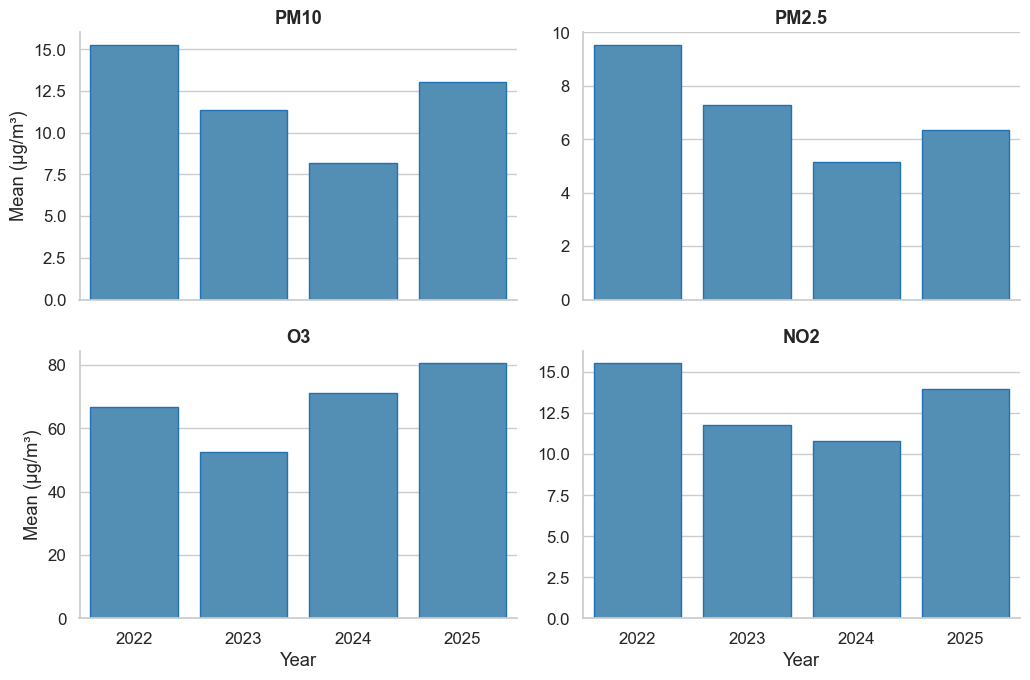

In [123]:
# Filter for May 12th to May 18th, years 2022-2025
years_filter = ['2022', '2023', '2024', '2025']
days_filter = ['12', '13', '14', '15', '16', '17', '18']

filtered_df = airquality[
    (airquality['Year'].isin(years_filter)) & 
    (airquality['Month'] == '05') & 
    (airquality['Day'].isin(days_filter))
]

# Calculate the average emissions per year for this specific week
annual_may_avg = filtered_df.groupby('Year')[emission_cols].mean().reset_index()

# Clean up the column names
display_names = {
    'PM10 (Stundenmittelwerte)': 'PM10',
    'PM2.5 (Stundenmittelwerte)': 'PM2.5',
    'O3 (Stundenmittelwerte)': 'O3',
    'NO2 (Stundenmittelwerte)': 'NO2'
}
annual_may_avg = annual_may_avg.rename(columns=display_names)

# Melt the data
df_long = annual_may_avg.melt(
    id_vars='Year', 
    value_vars=['PM10', 'PM2.5', 'O3', 'NO2'],
    var_name='Pollutant Type', 
    value_name='Average Concentration'
)

# Plot Design
plt.figure(figsize=(11, 6))
sns.set_theme(style='whitegrid', font_scale=1.1)
blue_palette = sns.color_palette('Blues', 4)
g = sns.FacetGrid(
    df_long, 
    col='Pollutant Type', 
    col_wrap=2, 
    height=3.5, 
    aspect=1.5, 
    sharey=False
)

#Create barplots
g.map_dataframe(sns.barplot, x="Year", y='Average Concentration', color='#4292c6', edgecolor='#2171b5')
g.set_titles(col_template='{col_name}', weight='bold')
g.set_axis_labels('Year', 'Mean (µg/m³)')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info" > These charts do not give us significant insight at first glance. PM10 and PM2.5 levels did not increase significantly compared to previous years.

However, there is a peak in O3 (Ozone) in May 2025. 

What is Ozone and what does it signify in this context?
"Tropospheric, or ground level ozone, is not emitted directly into the air, but is created by chemical reactions between oxides of nitrogen (NOx) and volatile organic compounds (VOC). This happens when pollutants emitted by cars, power plants, industrial boilers, refineries, chemical plants, and other sources chemically react in the presence of sunlight.

Ozone is most likely to reach unhealthy levels on hot sunny days in urban environments, but can still reach high levels during colder months. Ozone can also be transported long distances by wind, so even rural areas can experience high ozone levels."
([United States Environmental Protection Agency](https://www.epa.gov/ground-level-ozone-pollution/ground-level-ozone-basics))

This means that Ozone could have been generated by weather conditions, but also by pollution. Let's look into the days of May 2025 in detail.
</div>

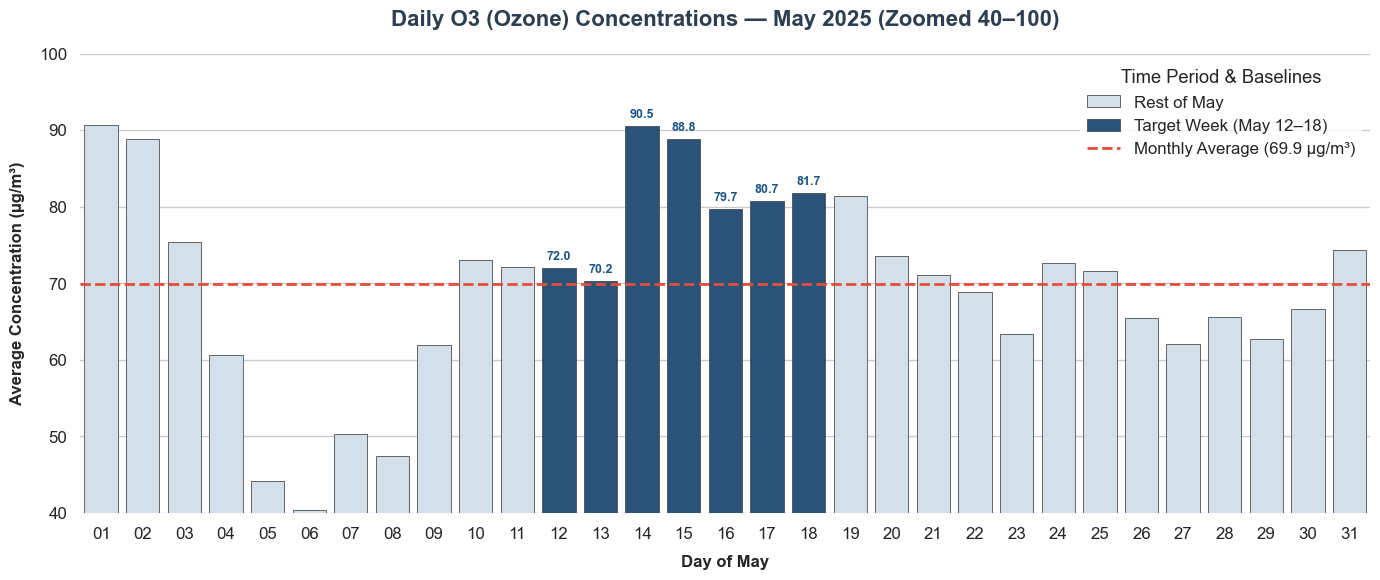

In [124]:
may_2025 = airquality[(airquality['Year'] == '2025') & (airquality['Month'] == '05')]

#Calculate the daily average for Ozone
o3_col = 'O3 (Stundenmittelwerte)'
may_2025_avg = may_2025.groupby('Day')[o3_col].mean().reset_index()
may_2025_avg = may_2025_avg.sort_values('Day')

# Calculate the overall monthly average
monthly_mean = may_2025_avg[o3_col].mean()

# Create Highlight labels
target_days = ['12', '13', '14', '15', '16', '17', '18']
may_2025_avg['Status'] = np.where(
    may_2025_avg['Day'].isin(target_days), 
    'Target Week (May 12–18)', 
    'Rest of May'
)

# Plot design
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid", font_scale=1.1)

custom_palette = {
    'Target Week (May 12–18)': '#1c5485',  # Vivid Slate Blue
    'Rest of May': '#d1e1ec'              # Muted Ice Blue
}

# Create barplot with average line
ax = sns.barplot(
    data=may_2025_avg, 
    x='Day', 
    y=o3_col, 
    hue='Status',
    palette=custom_palette,
    dodge=False,
    edgecolor='#4d4d4d',
    linewidth=0.6
)

ax.axhline(
    y=monthly_mean, 
    color='#e74c3c',       
    linestyle='--',       
    linewidth=2, 
    label=f'Monthly Average ({monthly_mean:.1f} µg/m³)'
)

x_labels = [text.get_text() for text in ax.get_xticklabels()]

for bar in ax.patches:
    height = bar.get_height()
    
    if height >= 40:  
        bar_center_x = bar.get_x() + bar.get_width() / 2
        day_index = int(round(bar_center_x))
        
        if 0 <= day_index < len(x_labels):
            day_value = x_labels[day_index]
            
            if day_value in target_days:
                ax.annotate(
                    f'{height:.1f}',
                    xy=(bar_center_x, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', 
                    va='bottom', 
                    fontsize=9, 
                    weight='bold', 
                    color='#1c5485'
                )

plt.title('Daily O3 (Ozone) Concentrations — May 2025 (Zoomed 40–100)', fontsize=16, pad=20, weight='bold', color='#2c3e50')
plt.xlabel('Day of May', fontsize=12, weight='semibold', labelpad=10)
plt.ylabel('Average Concentration (µg/m³)', fontsize=12, weight='semibold', labelpad=10)
plt.ylim(40, 100)
plt.legend(title='Time Period & Baselines', frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info" >This plot demonstrates above average ozone concentrations during Eurovision week, with a peak on May 14-15.</div>

<div class="alert alert-block alert-info" >Let's look at the correlation with NO2 emissions. Ozone concentrations increase when N02 emissions (from pollutants) react with sunny, warm weather conditions.</div>

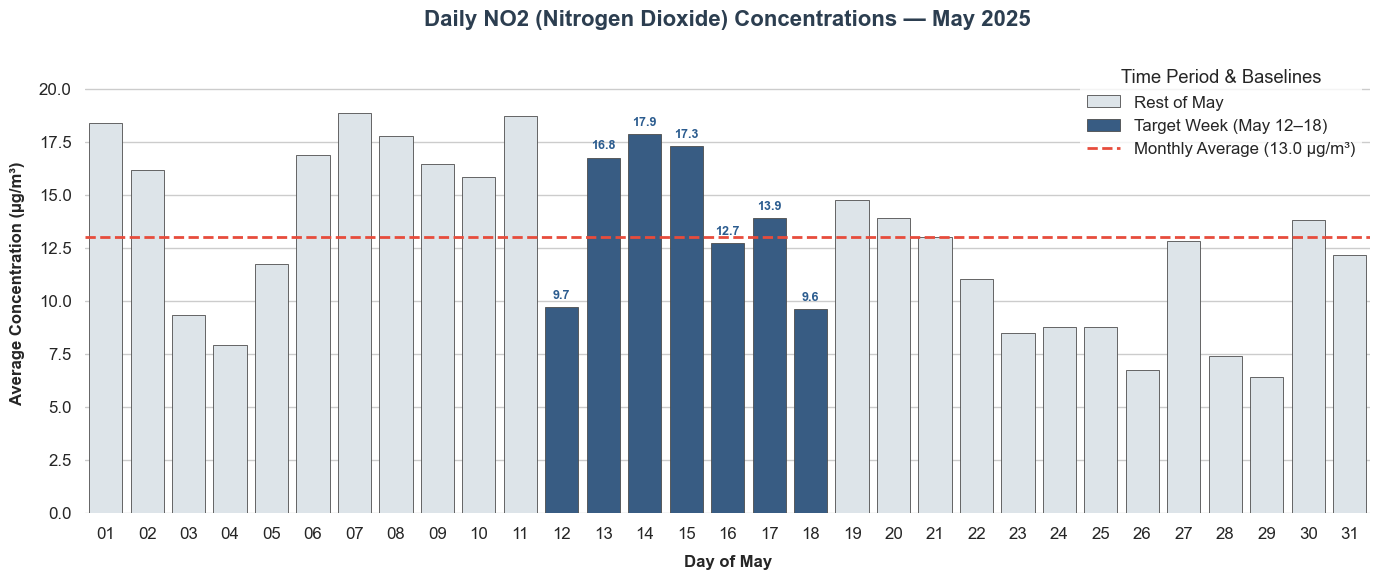

In [125]:
no2_col = 'NO2 (Stundenmittelwerte)'
may_2025_avg = may_2025.groupby('Day')[no2_col].mean().reset_index()
may_2025_avg = may_2025_avg.sort_values('Day')

# Calculate the overall monthly average for NO2
monthly_mean_no2 = may_2025_avg[no2_col].mean()

# Create Highlight labels
target_days = ['12', '13', '14', '15', '16', '17', '18']
may_2025_avg['Status'] = np.where(
    may_2025_avg['Day'].isin(target_days), 
    'Target Week (May 12–18)', 
    'Rest of May'
)

# Plot design
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid", font_scale=1.1)

custom_palette = {
    'Target Week (May 12–18)': '#2b5c8f',  # Dark Steel Blue
    'Rest of May': '#dbe4eb'              # Soft Slate Grey
}

# Create bar plot with average line
ax = sns.barplot(
    data=may_2025_avg, 
    x='Day', 
    y=no2_col, 
    hue='Status',
    palette=custom_palette,
    dodge=False,
    edgecolor='#4d4d4d',
    linewidth=0.6
)

ax.axhline(
    y=monthly_mean_no2, 
    color='#e74c3c',       # Red dashed baseline
    linestyle='--',       
    linewidth=2, 
    label=f'Monthly Average ({monthly_mean_no2:.1f} µg/m³)'
)

x_labels = [text.get_text() for text in ax.get_xticklabels()]

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  
        bar_center_x = bar.get_x() + bar.get_width() / 2
        day_index = int(round(bar_center_x))
        
        if 0 <= day_index < len(x_labels):
            day_value = x_labels[day_index]
            
            if day_value in target_days:
                ax.annotate(
                    f'{height:.1f}',
                    xy=(bar_center_x, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', 
                    va='bottom', 
                    fontsize=9, 
                    weight='bold', 
                    color='#2b5c8f'
                )

plt.title('Daily NO2 (Nitrogen Dioxide) Concentrations — May 2025', fontsize=16, pad=20, weight='bold', color='#2c3e50')
plt.xlabel('Day of May', fontsize=12, weight='semibold', labelpad=10)
plt.ylabel('Average Concentration (µg/m³)', fontsize=12, weight='semibold', labelpad=10)
plt.ylim(0, max(may_2025_avg[no2_col]) * 1.15)
plt.legend(title='Time Period & Baselines', frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info" > While a superficial glance at the data might suggest the Eurovision Song Contest caused an air quality crisis, cross-referencing O3 with NO3 reveals that pollution emissions during the event week were well within normal monthly variations. The pronounced Ozone spike during May 12–18 must have been was driven primarily by meteorological factors. </div>
    
<div class="alert alert-block alert-info" > Let's look at the maximum temperatures for the month.
</div>

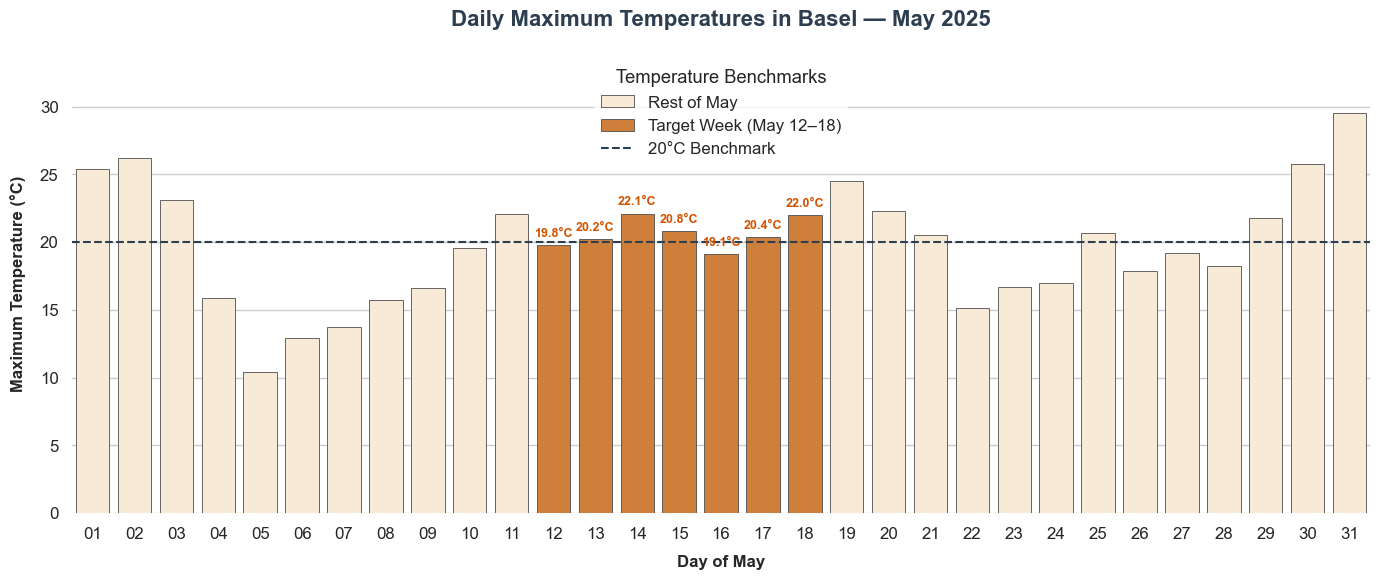

In [126]:
import requests

# Import historical weather data for Basel
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=47.5596&longitude=7.5886&"
    "start_date=2025-05-01&end_date=2025-05-31&"
    "daily=temperature_2m_max&timezone=Europe%2FBerlin"
)

response = requests.get(url).json()

# Build the data frame
df_weather = pd.DataFrame({
    'Date': response['daily']['time'],
    'Max_Temp': response['daily']['temperature_2m_max']
})

# Format the day column
df_weather['Day'] = df_weather['Date'].str.split('-').str[-1]

# Label the target Eurovision week
target_days = ['12', '13', '14', '15', '16', '17', '18']
df_weather['Status'] = np.where(
    df_weather['Day'].isin(target_days), 
    'Target Week (May 12–18)', 
    'Rest of May'
)

# Plot design
fig, ax = plt.subplots(figsize=(14, 6))
sns.set_theme(style="whitegrid", font_scale=1.1)

custom_palette = {
    'Target Week (May 12–18)': '#e67e22',  # Warm Amber
    'Rest of May': '#fdebd0'              # Light Peach
}

# Create barplot with reference line
sns.barplot(
    data=df_weather, 
    x='Day', 
    y='Max_Temp', 
    hue='Status',
    palette=custom_palette,
    dodge=False,
    edgecolor='#4d4d4d',
    linewidth=0.6,
    ax=ax
)

ax.axhline(
    y=20.0, 
    color='#2c3e50',       
    linestyle='--',       
    linewidth=1.5, 
    label='20°C Benchmark'
)

x_labels = [text.get_text() for text in ax.get_xticklabels()]

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  
        bar_center_x = bar.get_x() + bar.get_width() / 2
        day_index = int(round(bar_center_x))
        
        if 0 <= day_index < len(x_labels):
            day_value = x_labels[day_index]
            
            if day_value in target_days:
                ax.annotate(
                    f'{height:.1f}°C',
                    xy=(bar_center_x, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', 
                    va='bottom', 
                    fontsize=9, 
                    weight='bold', 
                    color='#d35400'
                )

ax.set_title('Daily Maximum Temperatures in Basel — May 2025', fontsize=16, pad=20, weight='bold', color='#2c3e50')
ax.set_xlabel('Day of May', fontsize=12, weight='semibold', labelpad=10)
ax.set_ylabel('Maximum Temperature (°C)', fontsize=12, weight='semibold', labelpad=10)
ax.set_ylim(0, max(df_weather['Max_Temp']) * 1.15)
ax.legend(title='Temperature Benchmarks', frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info" > This graph shows that the maximum temperatures during the event week were on average slightly above the rest of the month. These maximum temperatures are typical for the month of May in Basel. Being rather "warm" temperatures, they could be the primary reason for the O3 increase.</div>

<div class="alert alert-block alert-info" > Let's compare all our data side by side.</div>

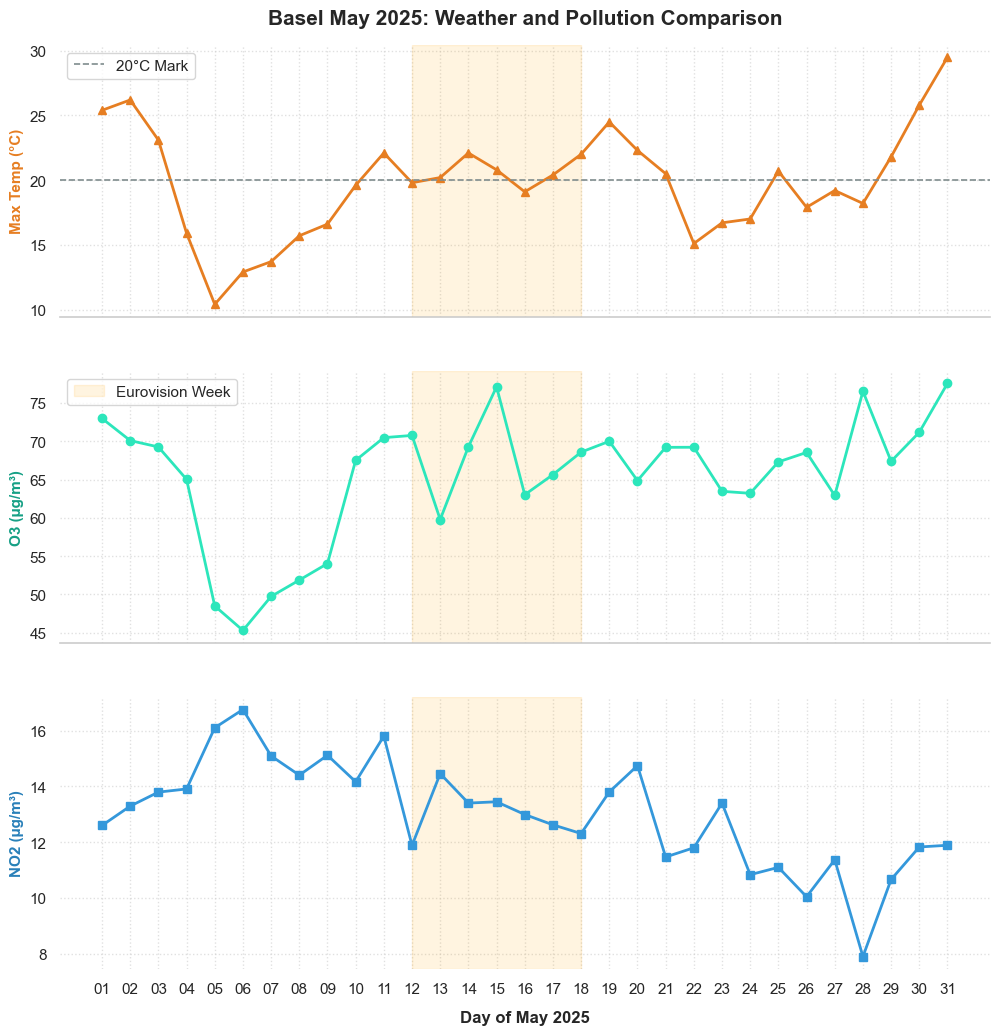

In [128]:

# Define column names
O3_COLUMN = 'O3 (Stundenmittelwerte)'   
NO2_COLUMN = 'NO2 (Stundenmittelwerte)' 
DAY_COLUMN = 'Day'

# Merge the three datasets
df_merged = pd.merge(df_air_daily, df_weather, on='Day').sort_values('Day')

# Create plots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
sns.set_theme(style='whitegrid', font_scale=1.0)

# Define target Eurovision week
target_start, target_end = '12', '18'
span_color = 'orange'
span_alpha = 0.12

# Plot 1: Maximum Temperature
ax1.plot(df_merged['Day'], df_merged['Max_Temp'], color='#e67e22', marker='^', linewidth=2)
ax1.set_ylabel('Max Temp (°C)', fontsize=11, weight='bold', color='#e67e22')
ax1.axhline(20.0, color='#7f8c8d', linestyle='--', linewidth=1.2, label='20°C Mark')
ax1.axvspan(target_start, target_end, color=span_color, alpha=span_alpha)
ax1.set_title('Basel May 2025: Weather and Pollution Comparison', fontsize=15, weight='bold', pad=15)
ax1.legend(loc='upper left', frameon=True, facecolor='white')

# Plot 2: Ozone
ax2.plot(df_merged['Day'], df_merged[O3_COLUMN], color='#2ce6bb', marker='o', linewidth=2)
ax2.set_ylabel('O3 (µg/m³)', fontsize=11, weight='bold', color='#16a085')
ax2.axvspan(target_start, target_end, color=span_color, alpha=span_alpha, label='Eurovision Week')
ax2.legend(loc='upper left', frameon=True, facecolor='white')

# Plot 3: Nitrogen Dioxide
ax3.plot(df_merged['Day'], df_merged[NO2_COLUMN], color='#3498db', marker='s', linewidth=2)
ax3.set_ylabel('NO2 (µg/m³)', fontsize=11, weight='bold', color='#2980b9')
ax3.axvspan(target_start, target_end, color=span_color, alpha=span_alpha)
ax3.set_xlabel('Day of May 2025', fontsize=12, weight='semibold', labelpad=10)

# Layout Adjustments
for ax in [ax1, ax2, ax3]:
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xticks(df_merged['Day']) 

sns.despine(left=True, bottom=True)

for ax in [ax1, ax2]:
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#cccccc')    
    ax.spines['bottom'].set_linewidth(1.2)       

plt.show()


<div class="alert alert-block alert-info" > Through this comparison, it now seems obvious that there have been no significant increases in pollution levels linked to Eurovision week.

The city of Basel and the organizers seem to have well executed this large-scale event. It boosted the local economy without causing any alarming harm to the environment.</div>